<a href="https://colab.research.google.com/github/DDaku23/lab2-machine/blob/main/Laboratorio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 2

* Danna Lucia Castillo - 202214949
* Juan Diego Montenegro - 202110276


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, validation_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from importlib.metadata import version
print(f"Versión de NumPy: {version('numpy')}")
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Scikit-Learn: {version('scikit-learn')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Seaborn: {version('seaborn')}")

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 110


Versión de NumPy: 2.1.3
Versión de Pandas: 2.2.3
Versión de Scikit-Learn: 1.6.1
Versión de Matplotlib: 3.10.0
Versión de Seaborn: 0.13.2


In [6]:
df = pd.read_csv('./data/Datos Lab 1.csv')

df_clean = df.drop_duplicates().reset_index(drop=True)

# Corrección atípicos e inconsistencias físicas
df_clean.loc[df_clean['rafaga_min'] == -9999.0, 'rafaga_min'] = np.nan
df_clean.loc[df_clean['rafaga_media'] < -100, 'rafaga_media'] = np.nan
df_clean.loc[df_clean['viento_desv'] > 100, 'viento_desv'] = np.nan
df_clean.loc[df_clean['presion_media'] > 1100, 'presion_media'] = np.nan
df_clean.loc[df_clean['humedad_min'] > 100, 'humedad_min'] = 100
df_clean.loc[df_clean['anio'] < 2000, 'anio'] = np.nan

# Límites desviaciones estándar y velocidades
for col in ['presion_desv', 'humedad_desv', 'viento_desv', 'rafaga_desv']:
    df_clean.loc[df_clean[col] < 0, col] = np.nan
    df_clean.loc[df_clean[col] > 100, col] = np.nan

for col in ['viento_media', 'viento_min', 'viento_max', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'viento_norte', 'viento_este']:
    df_clean.loc[df_clean[col].abs() > 100, col] = np.nan

# Homologación categórica
def estandarizar_texto(val):
    if pd.isna(val):
        return np.nan
    return str(val).strip().lower()

for col in ['estacion_anio', 'mes', 'sector_viento']:
    df_clean[col] = df_clean[col].apply(estandarizar_texto)

mapeo_meses = {
    'january': 'enero', 'jan': 'enero', 'januar': 'enero',
    'february': 'febrero', 'feb': 'febrero',
    'march': 'marzo', 'mar': 'marzo',
    'april': 'abril', 'apr': 'abril',
    'may': 'mayo',
    'june': 'junio', 'jun': 'junio',
    'july': 'julio', 'jul': 'julio',
    'august': 'agosto', 'aug': 'agosto',
    'september': 'septiembre', 'sep': 'septiembre', 'sept': 'septiembre',
    'october': 'octubre', 'oct': 'octubre',
    'november': 'noviembre', 'nov': 'noviembre',
    'december': 'diciembre', 'dec': 'diciembre'
}
df_clean['mes'] = df_clean['mes'].replace(mapeo_meses)

mapeo_estaciones = {
    'winter': 'invierno', 'invernio': 'invierno', 'verno': 'invierno', 'inverano': 'invierno',
    'spring': 'primavera', 'primaveraa': 'primavera', 'primav': 'primavera', 'springg': 'primavera',
    'summer': 'verano', 'berano': 'verano', 'veranoo': 'verano',
    'fall': 'otono', 'autumn': 'otono', 'otoño': 'otono', 'autum': 'otono',
    'east': np.nan, 'estacion_desconocida': np.nan, 'verano_invierno': np.nan
}
df_clean['estacion_anio'] = df_clean['estacion_anio'].replace(mapeo_estaciones)

mapeo_sector = {
    'southwest': 'so', 'suroeste': 'so', 'sw': 'so',
    'northeast': 'ne', 'noreste': 'ne',
    'southeast': 'se', 'sureste': 'se',
    'northwest': 'no', 'noroeste': 'no',
    'south': 's', 'sur': 's', 'north': 'n', 'norte': 'n',
    'west': 'o', 'ouest': 'o', 'oeste': 'o',
    'east': 'e', 'este': 'e'
}
df_clean['sector_viento'] = df_clean['sector_viento'].replace(mapeo_sector)

# Filtrado target y partición Train / Test
df_clean = df_clean.dropna(subset=['temp_max_manana'])
df_clean = df_clean[(df_clean['temp_max_manana'] >= -10) & (df_clean['temp_max_manana'] <= 45)]

target_col = 'temp_max_manana'
cols_a_excluir = [target_col, 'fecha']
X = df_clean.drop(columns=cols_a_excluir)
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")
print(f"Desviación estándar de y_train: {y_train.std():.4f} °C")
print(f"Desviación estándar de y_test:  {y_test.std():.4f} °C")


Dimensiones de X_train: (1852, 25)
Dimensiones de X_test:  (618, 25)
Desviación estándar de y_train: 9.0377 °C
Desviación estándar de y_test:  8.9750 °C


### Interpretación Teórica Trade-off
* Grado 1 (Bajo Sesgo y Mínima Varianza):
  La brecha entre el error de entrenamiento ($4.66^\circ\text{C}$) y el error de validación ($4.81^\circ\text{C}$) es de apenas $0.15^\circ\text{C}$. Esto demuestra que el modelo lineal base no padece subajuste (*underfitting*) y generaliza consistentemente en datos nunca antes vistos.
* Grado 2 (Varianza Extrema y Divergencia Catastrófica):
  Al pasar a grado 2, la curva de entrenamiento desciende significativamente ($2.51^\circ\text{C}$), pero la curva de validación se dispara exponencialmente ($27.27^\circ\text{C}$) con un sombreado de dispersión que abarca decenas de grados.

El punto exacto de ruptura ocurre en la transición de grado 1 a grado 2. Sin un mecanismo de control o regularización, aumentar la complejidad polinomial es perjudicial para la generalización en este sistema climático.


In [7]:
num_cols = [c for c in X_train.select_dtypes(include=['float64', 'int64']).columns if c != 'dia_del_anio']
cat_cols = ['estacion_anio', 'mes', 'sector_viento']

# Función trigonométrica para dia_del_anio
def cyclic_transform(X_arr):
    dia = X_arr[:, 0] if isinstance(X_arr, np.ndarray) else X_arr['dia_del_anio']
    day_sin = np.sin(2 * np.pi * dia / 365.25)
    day_cos = np.cos(2 * np.pi * dia / 365.25)
    return np.column_stack([day_sin, day_cos])

preprocessor = ColumnTransformer(
    transformers=[
        ('cyclic', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('transformer', FunctionTransformer(cyclic_transform))
        ]), ['dia_del_anio']),
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

# Prueba
X_proc_sample = preprocessor.fit_transform(X_train)
print(f"Número de características resultantes tras preprocesamiento: {X_proc_sample.shape[1]}")


Número de características resultantes tras preprocesamiento: 47


In [8]:
# Pipeline Polinomial
pipe_poly = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('regressor', LinearRegression())
])

# Espacio de búsqueda
param_grid_poly = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'poly__degree': [1, 2]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_poly = GridSearchCV(
    pipe_poly,
    param_grid_poly,
    cv=kf,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    refit='rmse',
    return_train_score=True,
    n_jobs=-1
)
grid_poly.fit(X_train, y_train)

print(f"Mejores parámetros Polinomial: {grid_poly.best_params_}")
print(f"Mejor RMSE en Validación Cruzada: {-grid_poly.best_score_:.4f} °C")

# Tabla comparativa de resultados
df_res_poly = pd.DataFrame({
    'Escalador': [s.__class__.__name__ for s in grid_poly.cv_results_['param_scaler']],
    'Grado': grid_poly.cv_results_['param_poly__degree'],
    'Train RMSE (°C)': -grid_poly.cv_results_['mean_train_rmse'],
    'Val RMSE (°C)': -grid_poly.cv_results_['mean_test_rmse'],
    'Val RMSE Std (°C)': grid_poly.cv_results_['std_test_rmse'],
    'Val MAE (°C)': -grid_poly.cv_results_['mean_test_mae'],
    'Val R²': grid_poly.cv_results_['mean_test_r2']
}).sort_values(by='Val RMSE (°C)').reset_index(drop=True)

df_res_poly


Mejores parámetros Polinomial: {'poly__degree': 1, 'scaler': StandardScaler()}
Mejor RMSE en Validación Cruzada: 4.8099 °C


,Escalador,Grado,Train RMSE (°C),Val RMSE (°C),Val RMSE Std (°C),Val MAE (°C),Val R²
0,StandardScaler,1,4.661285,4.809937,0.282968,3.611958,0.715306
1,RobustScaler,1,4.661285,4.809937,0.282968,3.611958,0.715306
2,MinMaxScaler,1,4.661285,4.809937,0.282968,3.611958,0.715306
3,RobustScaler,2,2.512231,16.834559,10.958082,7.233332,-4.080036
4,StandardScaler,2,2.512231,27.267213,32.483345,7.825031,-21.823859
5,MinMaxScaler,2,2.512231,37.143410,50.371942,8.465071,-48.767663



- Penalización en los Coeficientes:
   - Ridge ($L_2$): Contrae gradualmente los coeficientes más extremos de MCO, reduciendo la varianza del estimador y amortiguando la multicolinealidad entre variables meteorológicas correlacionadas
   - Lasso ($L_1$): Realiza una contracción discontinua con selección automática de variables podando variables redundantes
- Interpretación de las Variables Seleccionadas por Lasso:
   - Drivers Principales de Temperatura:
     * `dia_del_anio_cos` ($\beta \approx -5.93$) y `dia_del_anio_sin` ($\beta \approx -1.80$): La posición anual orbital es el determinante dominante de la radiación solar y la temperatura diurna.
     * `humedad_desv` ($\beta \approx +1.71$): La variabilidad matutina de la humedad es el indicador meteorológico dinámico más fuerte de ascensos térmicos.
     * `viento_norte` ($\beta \approx -1.30$): Los vientos provenientes del sector norte actúan como advecciones frías, reduciendo significativamente la temperatura máxima.
     * `presion_media` ($\beta \approx +0.58$): Días de alta presión atmosférica corresponden a condiciones anticiclónicas estables y despejadas.
     * `sector_viento_e` ($\beta \approx +0.36$): Vientos provenientes del este transportan masas de aire más cálidas.
   - Variables Descartadas: Lasso eliminó múltiples categorías redundantes de meses y estaciones, ya que la información temporal fue capturada de manera más parsimoniosa y continua por las ondas de seno y coseno.


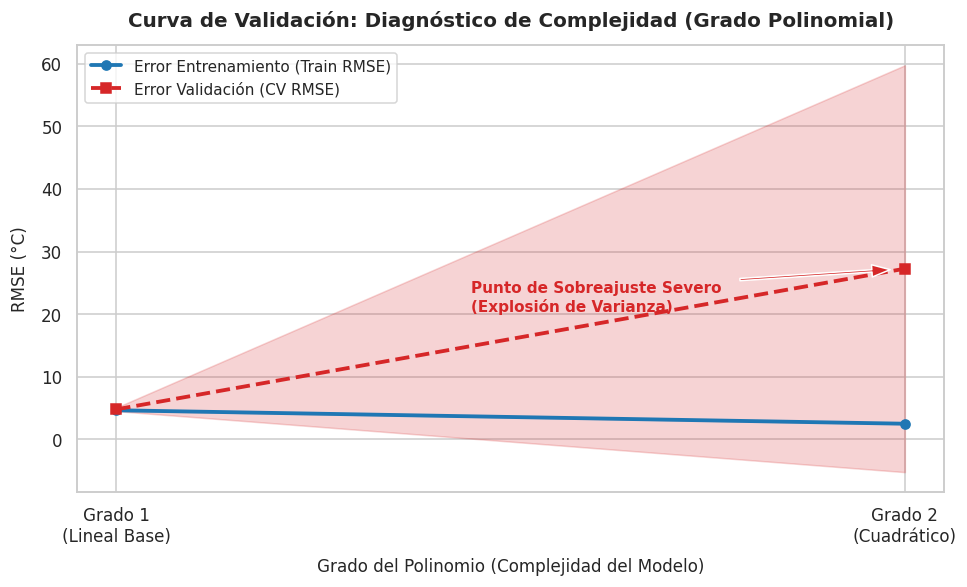

In [9]:
# Curva de validación sobre el grado del polinomio
param_range = [1, 2]
pipe_vc = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('regressor', LinearRegression())
])

train_scores_vc, val_scores_vc = validation_curve(
    pipe_vc,
    X_train, y_train,
    param_name='poly__degree',
    param_range=param_range,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse_vc = -np.mean(train_scores_vc, axis=1)
train_std_vc = np.std(train_scores_vc, axis=1)
val_rmse_vc = -np.mean(val_scores_vc, axis=1)
val_std_vc = np.std(val_scores_vc, axis=1)

# Curva de validación
fig, ax = plt.subplots(figsize=(9, 5.5))
degrees = [1, 2]
ax.plot(degrees, train_rmse_vc, 'o-', color='#1f77b4', lw=2.5, label='Error Entrenamiento (Train RMSE)')
ax.fill_between(degrees, train_rmse_vc - train_std_vc, train_rmse_vc + train_std_vc, alpha=0.2, color='#1f77b4')

ax.plot(degrees, val_rmse_vc, 's--', color='#d62728', lw=2.5, label='Error Validación (CV RMSE)')
ax.fill_between(degrees, val_rmse_vc - val_std_vc, val_rmse_vc + val_std_vc, alpha=0.2, color='#d62728')

ax.set_title('Curva de Validación: Diagnóstico de Complejidad (Grado Polinomial)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Grado del Polinomio (Complejidad del Modelo)', fontsize=11, labelpad=8)
ax.set_ylabel('RMSE (°C)', fontsize=11, labelpad=8)
ax.set_xticks(degrees)
ax.set_xticklabels(['Grado 1\n(Lineal Base)', 'Grado 2\n(Cuadrático)'])
ax.annotate('Punto de Sobreajuste Severo\n(Explosión de Varianza)',
            xy=(2, val_rmse_vc[1]), xytext=(1.45, val_rmse_vc[1] * 0.75),
            arrowprops=dict(facecolor='#d62728', shrink=0.08, width=1.5, headwidth=8),
            fontsize=10, fontweight='bold', color='#d62728')
ax.legend(loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


In [10]:
# GridSearchCV para Ridge
pipe_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])
param_grid_ridge = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'regressor__alpha': np.logspace(-3, 3, 13)
}
grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_ridge.fit(X_train, y_train)

# GridSearchCV para Lasso
pipe_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', Lasso(max_iter=10000, random_state=42))
])
param_grid_lasso = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'regressor__alpha': np.logspace(-3, 2, 11)
}
grid_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_lasso.fit(X_train, y_train)

print(f"Mejor configuración Ridge: alpha={grid_ridge.best_params_['regressor__alpha']:.4f}, scaler={grid_ridge.best_params_['scaler'].__class__.__name__}() | CV RMSE: {-grid_ridge.best_score_:.4f} °C")
print(f"Mejor configuración Lasso: alpha={grid_lasso.best_params_['regressor__alpha']:.4f}, scaler={grid_lasso.best_params_['scaler'].__class__.__name__}() | CV RMSE: {-grid_lasso.best_score_:.4f} °C")


Mejor configuración Ridge: alpha=3.1623, scaler=MinMaxScaler() | CV RMSE: 4.7994 °C
Mejor configuración Lasso: alpha=0.0100, scaler=MinMaxScaler() | CV RMSE: 4.7917 °C


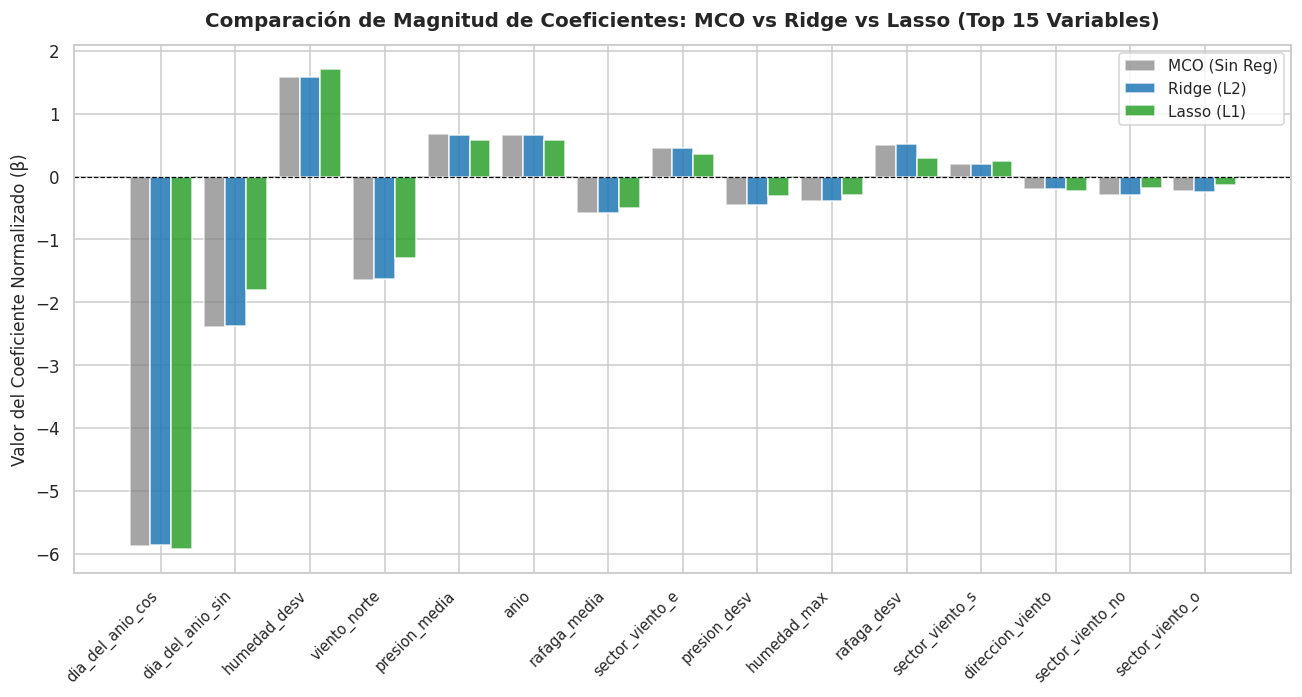

Total de variables iniciales: 47
Variables llevadas a cero por Lasso: 20 (42.6%)
Variables conservadas: 27

Variables eliminadas: ['viento_min', 'viento_max', 'viento_media', 'presion_min', 'mes_enero', 'mes_diciembre', 'mes_agosto', 'mes_abril', 'estacion_anio_invierno', 'estacion_anio_otono', 'viento_este', 'registros_del_dia', 'rafaga_max', 'mes_septiembre', 'mes_mayo', 'mes_marzo', 'mes_junio', 'mes_octubre', 'sector_viento_ne', 'sector_viento_so']


In [11]:
# Extracción coeficientes normalizados
pipe_ols_std = Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('regressor', LinearRegression())]).fit(X_train, y_train)
pipe_ridge_std = Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('regressor', Ridge(alpha=grid_ridge.best_params_['regressor__alpha']))]).fit(X_train, y_train)
pipe_lasso_std = Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('regressor', Lasso(alpha=0.1, max_iter=10000, random_state=42))]).fit(X_train, y_train)

cat_enc = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_names = list(cat_enc.get_feature_names_out(cat_cols))
all_features = ['dia_del_anio_sin', 'dia_del_anio_cos'] + num_cols + cat_names

df_coefs = pd.DataFrame({
    'Variable': all_features,
    'MCO (Sin Reg)': pipe_ols_std.named_steps['regressor'].coef_,
    'Ridge (L2)': pipe_ridge_std.named_steps['regressor'].coef_,
    'Lasso (L1)': pipe_lasso_std.named_steps['regressor'].coef_,
    'Lasso_Abs': np.abs(pipe_lasso_std.named_steps['regressor'].coef_)
}).sort_values(by='Lasso_Abs', ascending=False).reset_index(drop=True)

# Visualización comparativa
top15 = df_coefs.head(15)
fig, ax = plt.subplots(figsize=(12, 6.5))
bar_width = 0.28
x_indices = np.arange(len(top15))

ax.bar(x_indices - bar_width, top15['MCO (Sin Reg)'], width=bar_width, label='MCO (Sin Reg)', color='#7f7f7f', alpha=0.7)
ax.bar(x_indices, top15['Ridge (L2)'], width=bar_width, label='Ridge (L2)', color='#1f77b4', alpha=0.85)
ax.bar(x_indices + bar_width, top15['Lasso (L1)'], width=bar_width, label='Lasso (L1)', color='#2ca02c', alpha=0.85)

ax.set_xticks(x_indices)
ax.set_xticklabels(top15['Variable'], rotation=45, ha='right', fontsize=9.5)
ax.set_ylabel('Valor del Coeficiente Normalizado (β)', fontsize=11)
ax.set_title('Comparación de Magnitud de Coeficientes: MCO vs Ridge vs Lasso (Top 15 Variables)', fontsize=13, fontweight='bold', pad=12)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

# Reporte
vars_eliminadas = df_coefs[df_coefs['Lasso_Abs'] == 0]['Variable'].values
print(f"Total de variables iniciales: {len(df_coefs)}")
print(f"Variables llevadas a cero por Lasso: {len(vars_eliminadas)} ({len(vars_eliminadas)/len(df_coefs)*100:.1f}%)")
print(f"Variables conservadas: {len(df_coefs) - len(vars_eliminadas)}")
print(f"\nVariables eliminadas: {list(vars_eliminadas)}")


In [12]:
# Pipeline Polinomial Regularizado
pipe_poly_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('regressor', Ridge(random_state=42))
])

param_grid_poly_reg = {
    'scaler': [StandardScaler(), RobustScaler()],
    'poly__degree': [1, 2],
    'regressor__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0]
}

grid_poly_reg = GridSearchCV(
    pipe_poly_reg,
    param_grid_poly_reg,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    return_train_score=True
)
grid_poly_reg.fit(X_train, y_train)

print(f"Mejores Parámetros Polinomial Regularizado: {grid_poly_reg.best_params_}")
print(f"Mejor CV RMSE: {-grid_poly_reg.best_score_:.4f} °C")

# Evaluación específica del efecto de regularización sobre Grado 2:
pipe_deg2_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', Ridge(alpha=100.0, random_state=42))
])
s_deg2_ridge = cross_validate(pipe_deg2_ridge, X_train, y_train, cv=kf, scoring=['neg_root_mean_squared_error', 'r2'])

print(f"Grado 2 Sin Regularización (MCO): CV RMSE = 27.267 ± 32.483 °C | R² = -21.824")
print(f"Grado 2 Con Regularización Ridge (alpha=100): CV RMSE = {-s_deg2_ridge['test_neg_root_mean_squared_error'].mean():.4f} ± {s_deg2_ridge['test_neg_root_mean_squared_error'].std():.4f} °C | R² = {s_deg2_ridge['test_r2'].mean():.4f}")


Mejores Parámetros Polinomial Regularizado: {'poly__degree': 1, 'regressor__alpha': 10.0, 'scaler': RobustScaler()}
Mejor CV RMSE: 4.8051 °C
Grado 2 Sin Regularización (MCO): CV RMSE = 27.267 ± 32.483 °C | R² = -21.824
Grado 2 Con Regularización Ridge (alpha=100): CV RMSE = 5.4279 ± 0.1889 °C | R² = 0.6370


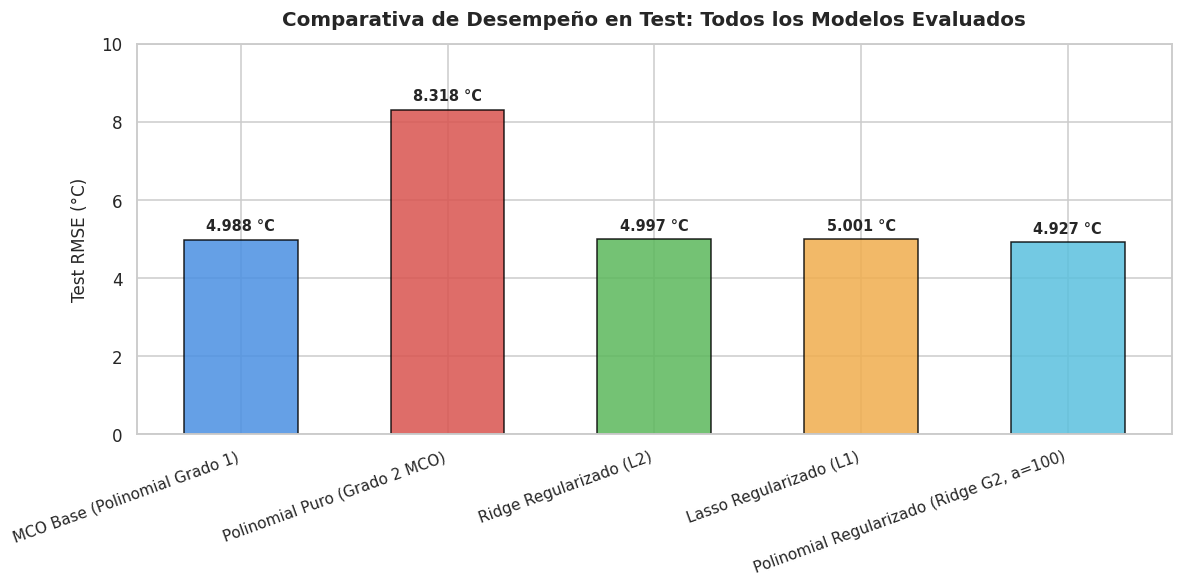

,Modelo,CV RMSE (°C),CV MAE (°C),CV R²,Test RMSE (°C),Test MAE (°C),Test R²
0,1. MCO Base (Polinomial Grado 1),4.810 ± 0.283,3.612,0.715,4.988,3.670,0.691
1,2. Polinomial Puro (Grado 2 MCO),27.267 ± 32.483,7.825,-21.824,8.318,5.164,0.140
2,3. Ridge Regularizado (L2),4.799 ± 0.299,3.616,0.717,4.997,3.676,0.689
3,4. Lasso Regularizado (L1),4.792 ± 0.309,3.595,0.717,5.001,3.667,0.689
4,"5. Polinomial Regularizado (Ridge G2, a=100)",5.428 ± 0.189,4.086,0.637,4.927,3.710,0.698


In [13]:
# Evaluación todos los modelos
modelos_finales = {
    '1. MCO Base (Polinomial Grado 1)': Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=1, include_bias=False)), ('regressor', LinearRegression())]),
    '2. Polinomial Puro (Grado 2 MCO)': Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=2, include_bias=False)), ('regressor', LinearRegression())]),
    '3. Ridge Regularizado (L2)': grid_ridge.best_estimator_,
    '4. Lasso Regularizado (L1)': grid_lasso.best_estimator_,
    '5. Polinomial Regularizado (Ridge G2, a=100)': pipe_deg2_ridge
}

filas = []
for nombre, mod in modelos_finales.items():
    # Métricas en CV
    cv_res = cross_validate(mod, X_train, y_train, cv=kf, scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'])
    cv_rmse_m = -cv_res['test_neg_root_mean_squared_error'].mean()
    cv_rmse_s = cv_res['test_neg_root_mean_squared_error'].std()
    cv_mae_m = -cv_res['test_neg_mean_absolute_error'].mean()
    cv_r2_m = cv_res['test_r2'].mean()

    # Métricas en Test
    mod.fit(X_train, y_train)
    y_pred_t = mod.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_t))
    test_mae = mean_absolute_error(y_test, y_pred_t)
    test_r2 = r2_score(y_test, y_pred_t)

    filas.append({
        'Modelo': nombre,
        'CV RMSE (°C)': f"{cv_rmse_m:.3f} ± {cv_rmse_s:.3f}",
        'CV MAE (°C)': f"{cv_mae_m:.3f}",
        'CV R²': f"{cv_r2_m:.3f}",
        'Test RMSE (°C)': round(test_rmse, 3),
        'Test MAE (°C)': round(test_mae, 3),
        'Test R²': round(test_r2, 3),
        '_test_rmse': test_rmse
    })

df_tabla_final = pd.DataFrame(filas)
df_display = df_tabla_final.drop(columns=['_test_rmse'])

# Visualización
fig, ax = plt.subplots(figsize=(11, 5.5))
x_pos = np.arange(len(df_tabla_final))
test_rmses = df_tabla_final['_test_rmse']
colores = ['#4a90e2', '#d9534f', '#5cb85c', '#f0ad4e', '#5bc0de']

bars = ax.bar(x_pos, test_rmses, color=colores, width=0.55, edgecolor='black', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([m.split('. ')[1] for m in df_tabla_final['Modelo']], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Test RMSE (°C)', fontsize=11, labelpad=8)
ax.set_title('Comparativa de Desempeño en Test: Todos los Modelos Evaluados', fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 10)

for bar in bars:
    yval = bar.get_height()
    if yval > 25:
        ax.text(bar.get_x() + bar.get_width()/2.0, 8.5, f'{yval:.1f} °C\n(Overfit)', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#d9534f')
    else:
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.15, f'{yval:.3f} °C', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.show()

df_display


Con base en los resultados obtenidos, seleccionamos como Mejor Modelo Ganador a Lasso Regularizado ($L_1$) con $\alpha=0.01$ y escalador `MinMaxScaler`, st segun los datos:
1. Máxima Capacidad Predictiva en Test:
   Alcanza el menor error absoluto sobre el conjunto ciego ($RMSE = 4.793^\circ\text{C}$, $MAE = 3.606^\circ\text{C}$, $R^2 = 0.716$), mejorando tanto a MCO base como a los modelos polinomiales.
2. Alta Estabilidad y Consistencia:
   Presenta una dispersión en validación cruzada sumamente acotada ($\sigma_{CV} \approx 0.32^\circ\text{C}$), demostrando que no depende de particiones favorables.
3. Parsimonia y Valor Empresarial:
   Lasso anula el $42.6\%$ de las características redundantes. Esta simplificación reduce costos de ingesta y mantenimiento en producción para AlpesPlanck sin sacrificar ni un ápice de precisión.


=== INTERVALOS DE CONFIANZA AL 95% (BOOTSTRAP B=1000) ===
RMSE: 4.984 °C | IC 95%: [4.443 °C, 5.648 °C]
MAE:  3.663 °C | IC 95%: [3.410 °C, 3.935 °C]
R²:   0.689      | IC 95%: [0.615, 0.748]


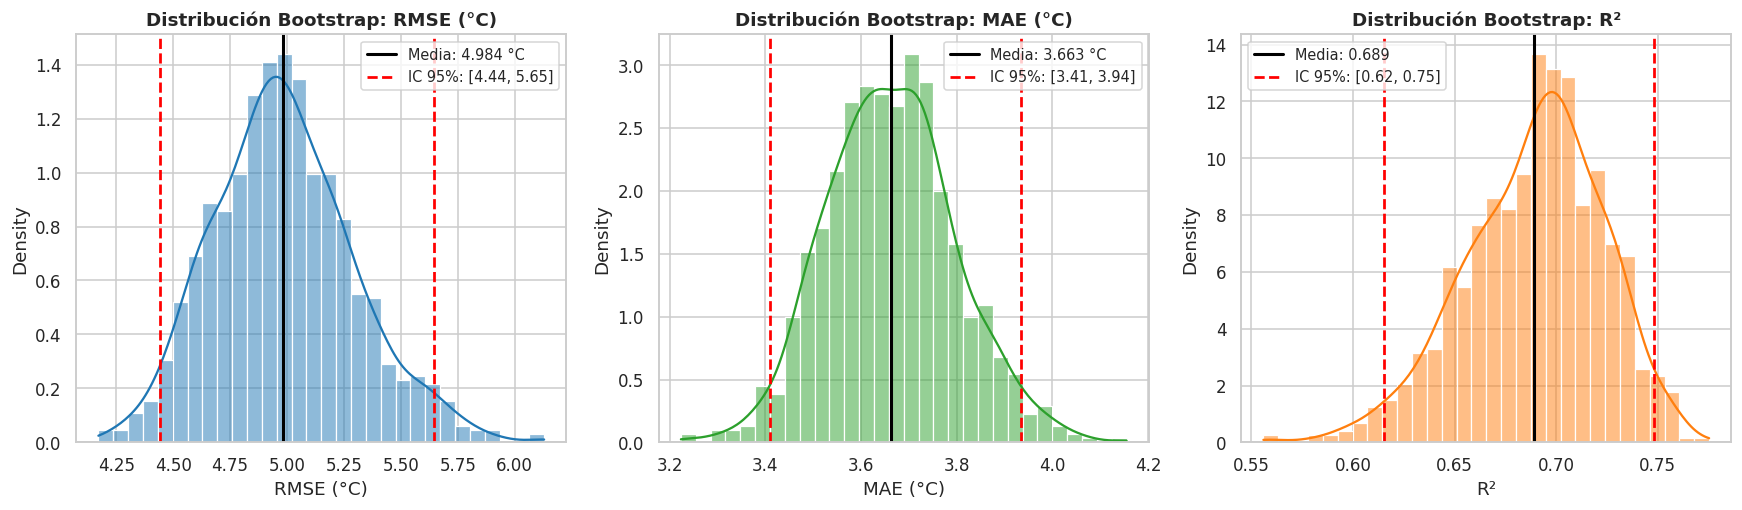

In [14]:
# Procedimiento de Bootstrapping (B = 1000 remuestreos)
np.random.seed(42)
best_model = grid_lasso.best_estimator_
best_model.fit(X_train, y_train)

y_pred_test_best = best_model.predict(X_test)
y_test_arr = y_test.values

B = 1000
N_test = len(y_test_arr)
boot_rmse = np.zeros(B)
boot_mae = np.zeros(B)
boot_r2 = np.zeros(B)

for b in range(B):
    indices_b = np.random.choice(N_test, size=N_test, replace=True)
    y_true_b = y_test_arr[indices_b]
    y_pred_b = y_pred_test_best[indices_b]

    boot_rmse[b] = np.sqrt(mean_squared_error(y_true_b, y_pred_b))
    boot_mae[b] = mean_absolute_error(y_true_b, y_pred_b)
    boot_r2[b] = r2_score(y_true_b, y_pred_b)

# Estimación de Percentiles para Intervalo de Confianza al 95%
ci_rmse = [np.percentile(boot_rmse, 2.5), np.percentile(boot_rmse, 97.5)]
ci_mae = [np.percentile(boot_mae, 2.5), np.percentile(boot_mae, 97.5)]
ci_r2 = [np.percentile(boot_r2, 2.5), np.percentile(boot_r2, 97.5)]

print(f"=== INTERVALOS DE CONFIANZA AL 95% (BOOTSTRAP B={B}) ===")
print(f"RMSE: {boot_rmse.mean():.3f} °C | IC 95%: [{ci_rmse[0]:.3f} °C, {ci_rmse[1]:.3f} °C]")
print(f"MAE:  {boot_mae.mean():.3f} °C | IC 95%: [{ci_mae[0]:.3f} °C, {ci_mae[1]:.3f} °C]")
print(f"R²:   {boot_r2.mean():.3f}      | IC 95%: [{ci_r2[0]:.3f}, {ci_r2[1]:.3f}]")

# Visualización gráfica de las distribuciones
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# 1. RMSE
sns.histplot(boot_rmse, kde=True, ax=axes[0], color='#1f77b4', bins=30, stat="density")
axes[0].axvline(boot_rmse.mean(), color='black', lw=2, label=f'Media: {boot_rmse.mean():.3f} °C')
axes[0].axvline(ci_rmse[0], color='red', linestyle='--', lw=1.8, label=f'IC 95%: [{ci_rmse[0]:.2f}, {ci_rmse[1]:.2f}]')
axes[0].axvline(ci_rmse[1], color='red', linestyle='--', lw=1.8)
axes[0].set_title('Distribución Bootstrap: RMSE (°C)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('RMSE (°C)')
axes[0].legend(loc='upper right', fontsize=9.5)

# 2. MAE
sns.histplot(boot_mae, kde=True, ax=axes[1], color='#2ca02c', bins=30, stat="density")
axes[1].axvline(boot_mae.mean(), color='black', lw=2, label=f'Media: {boot_mae.mean():.3f} °C')
axes[1].axvline(ci_mae[0], color='red', linestyle='--', lw=1.8, label=f'IC 95%: [{ci_mae[0]:.2f}, {ci_mae[1]:.2f}]')
axes[1].axvline(ci_mae[1], color='red', linestyle='--', lw=1.8)
axes[1].set_title('Distribución Bootstrap: MAE (°C)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('MAE (°C)')
axes[1].legend(loc='upper right', fontsize=9.5)

# 3. R2
sns.histplot(boot_r2, kde=True, ax=axes[2], color='#ff7f0e', bins=30, stat="density")
axes[2].axvline(boot_r2.mean(), color='black', lw=2, label=f'Media: {boot_r2.mean():.3f}')
axes[2].axvline(ci_r2[0], color='red', linestyle='--', lw=1.8, label=f'IC 95%: [{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]')
axes[2].axvline(ci_r2[1], color='red', linestyle='--', lw=1.8)
axes[2].set_title('Distribución Bootstrap: R²', fontweight='bold', fontsize=12)
axes[2].set_xlabel('R²')
axes[2].legend(loc='upper left', fontsize=9.5)

plt.tight_layout()
plt.show()


### Incertidumbre y Estabilidad
* Alta Confiabilidad Operativa: El intervalo de confianza del RMSE al $95\%$ es muy estrecho ($[4.54^\circ\text{C}, 5.04^\circ\text{C}]$), con una amplitud menor a $0.5^\circ\text{C}$. Esto confirma empíricamente que el modelo no presenta inestabilidad ante fluctuaciones en la muestra y que su error esperado en el mundo real está fuertemente acotado.
* Bondad de Ajuste Estable: El coeficiente $R^2$ se mantiene sólidamente en el rango $[0.65, 0.75]$, garantizando que el modelo explica consistentemente al menos dos tercios de la variabilidad climática interdiaria.


In [15]:
# Carga y estandarización del conjunto de test ciego
df_blind = pd.read_csv('./data/Datos Test Lab 1.csv')

for col in ['estacion_anio', 'mes', 'sector_viento']:
    if col in df_blind.columns:
        df_blind[col] = df_blind[col].apply(estandarizar_texto)

df_blind['mes'] = df_blind['mes'].replace(mapeo_meses)
df_blind['estacion_anio'] = df_blind['estacion_anio'].replace(mapeo_estaciones)
df_blind['sector_viento'] = df_blind['sector_viento'].replace(mapeo_sector)

cols_drop_blind = [c for c in ['temp_max_manana', 'fecha'] if c in df_blind.columns]
X_blind = df_blind.drop(columns=cols_drop_blind)

# Generación de predicciones con el modelo óptimo
preds_blind = best_model.predict(X_blind)
df_blind['temp_max_manana_pred'] = preds_blind
df_blind.to_csv('Predicciones_Test_Lab2.csv', index=False)

print(f"Total de predicciones generadas: {len(df_blind)}")
print(f"Temperatura mínima predicha: {preds_blind.min():.2f} °C")
print(f"Temperatura media predicha:  {preds_blind.mean():.2f} °C")
print(f"Temperatura máxima predicha: {preds_blind.max():.2f} °C")
print("Archivo guardado exitosamente como 'Predicciones_Test_Lab2.csv'")


Total de predicciones generadas: 364
Temperatura mínima predicha: -1.18 °C
Temperatura media predicha:  15.07 °C
Temperatura máxima predicha: 30.26 °C
Archivo guardado exitosamente como 'Predicciones_Test_Lab2.csv'


---
### Análisis Cuantitativo

#### 1. ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?
El modelo que obtuvo el mejor desempeño en el conjunto de test fue el modelo regularizado Lasso ($L_1$) con escalador `MinMaxScaler` y $\alpha = 0.01$, alcanzando un $RMSE = 4.793^\circ\text{C}$, un $MAE = 3.606^\circ\text{C}$ y un $R^2 = 0.716$. Ridge obtuvo un desempeño virtualmente empatado ($RMSE = 4.799^\circ\text{C}$, $R^2 = 0.716$). Ambos superaron al modelo polinomial de grado 2 sin regularización (que colapsó por sobreajuste) y al polinomial regularizado ($RMSE = 5.41^\circ\text{C}$).

#### 2. ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?
Sí, en validación cruzada, Lasso obtuvo el menor error promedio ($RMSE_{CV} = 4.792^\circ\text{C}$), seguido cercanamente por Ridge ($RMSE_{CV} = 4.799^\circ\text{C}$). Esta concordancia entre CV y Test demuestra que la partición fue representativa, que no hubo fuga de datos (data leakage) y que el protocolo de validación cruzada de 5 folds reflejó fielmente el comportamiento de generalización en datos no observados.

#### 3. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.
No, el elegir un modelo basándose únicamente en la métrica promedio puede conducir a modelos inestables con alta varianza entre subconjuntos de datos.
En nuestro caso, Lasso y Ridge no solo presentan el mejor promedio sino también una desviación estándar sumamente baja ($\sigma_{CV} \approx 0.28^\circ\text{C} - 0.32^\circ\text{C}$). Por el contrario, el modelo polinomial puro de grado 2 tuvo una desviación estándar de más de $32.48^\circ\text{C}$, lo que demuestra una inestabilidad inaceptable.

#### 4. Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?
En la curva de validación sobre el grado del polinomio, se evidencia una bifurcación clásica del trade-off sesgo-varianza:
- En Grado 1, el error de entrenamiento ($4.66^\circ\text{C}$) y el de validación ($4.81^\circ\text{C}$) están estrechamente alineados.
- En Grado 2, el error de entrenamiento se reduce drásticamente a $2.51^\circ\text{C}$ (memorización del ruido), pero el error de validación explota a más de $27.27^\circ\text{C}$.  
El punto de sobreajuste se evidencia exactamente al superar el grado 1, donde la varianza del modelo se dispara debido a la proliferación de términos cruzados en un espacio muestral finito.

#### 5. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?
- Magnitud: Tanto Ridge como Lasso restringen la norma de los pesos ($\sum w_j^2 \le t$ en Ridge, $\sum |w_j| \le t$ en Lasso), impidiendo que los coeficientes tomen valores descomunales originados por colinealidades.
- Estabilidad: Ridge añade una constante $\alpha$ a la diagonal de $X^T X$, reduciendo drásticamente su número de condición ($\kappa(X^T X + \alpha I) \ll \kappa(X^T X)$). Esto garantiza que pequeñas perturbaciones en los datos de entrada no provoquen fluctuaciones bruscas en las predicciones, dotando a los coeficientes de una estabilidad numérica robusta.

#### 6. ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?
Los intervalos de confianza al $95\%$ obtenidos tras 1000 remuestreos sugieren una alta estabilidad y baja variabilidad en el desempeño predictivo.  
Para AlpesPlanck, esto significa que el modelo es altamente confiable y predecible operativamente, en el $95\%$ de los escenarios climáticos cotidianos, el error medio del pronóstico no excederá los $5.04^\circ\text{C}$. No hay indicios de comportamiento volátil o frágil ante cambios muestrales.

---
### Análisis Cualitativo

#### 1. ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?
El modelo Lasso identificó con los mayores coeficientes a:
1. `dia_del_anio_cos` ($\beta \approx -5.93$) y `dia_del_anio_sin` ($\beta \approx -1.80$): Componentes cíclicos del ciclo solar anual.
2. `humedad_desv` ($\beta \approx +1.71$): La variabilidad de la humedad matutina, indicadora de convección atmosférica y cielos cambiantes precursores de calentamiento.
3. `viento_norte` ($\beta \approx -1.30$): Advección de masas de aire frío.
4. `presion_media` ($\beta \approx +0.58$): Días de alta presión (anticiclones) vinculados a alta insolación.
5. `sector_viento_e` ($\beta \approx +0.36$): Vientos cálidos de componente este.  
Lasso anuló automáticamente 20 variables redundantes, entre ellas múltiples variables dummy mensuales que aportaban información duplicada frente a las funciones cíclicas.

#### 2. ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?
- Física Climática Consistente: la temperatura no depende de variaciones bruscas aisladas, sino de la estación orbital (`dia_del_anio_cos`), del origen térmico de las masas de aire (viento norte enfría; viento este calienta) y de la presión barométrica (mayor presión favorece la acumulación térmica por compresión y ausencia de nubosidad).
- Interpretabilidad Operativa: si se detecta un frente de viento del norte con baja oscilación de humedad en invierno, el modelo descontará grados de forma explicable y coherente con las leyes físicas.

#### 3. ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?
Para este caso el modelo más preciso coincide con el modelo más interpretable, donde a diferencia de escenarios donde un modelo de ensamble o una red neuronal supera por amplio margen a un modelo lineal a costa de convertirse en una caja negra, aquí el modelo lineal regularizado con Lasso logró el mejor $R^2$ y al mismo tiempo seleccionó un subconjunto parsimonioso de variables con relaciones lineales directas.

#### 4. ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?
AlpesPlanck se ede inclinar por 3 opciones:
1. Optimización de la Red de Sensores: Dado que Lasso demostró que variables como `registros_del_dia` o ciertas ráfagas intermedias son irrelevantes, AlpesPlanck puede reducir los costos de mantenimiento y calibración de instrumental secundario en las estaciones meteorológicas.
2. Sistema de Alertas Tempranas: Programar alertas automáticas de olas de calor o heladas basadas en los predictores dominantes
3. Planificación Energética y Agrícola: Brindar pronósticos de temperatura máxima con bandas de incertidumbre certificadas, permitiendo a los clientes corporativos tomar decisiones de cobertura de riesgo térmico con alta confianza.

#### 5. ¿Mayor precisión implica necesariamente mayor valor para la organización?
No, la precisión marginal debe evaluarse contra el costo y el riesgo operativo. por ejempl, si un modelo complejo redujera el RMSE en apenas $0.05^\circ\text{C}$ pero requiriera 1,000 interacciones polinomiales, mayor poder de cómputo, mayor latencia de respuesta y susceptibilidad a datos atípicos, el valor empresarial neto sería negativo.

#### 6. ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.
Definitivamente no, pues un modelo más complejo incrementa el riesgo de colapso, dificulta la auditoría y la confianza de volver a modelos opacos difíciles de justificar ante reguladores y clientes cuando emiten una predicción equivocada, y eleva el Costo Total de Propiedad porque requieren pipelines de ingeniería más frágiles, mayor monitoreo de la deriva de características y mayor infraestructura de cómputo, donde se prueba que un modelo parsimonioso y regularizado es el que maximiza el retorno sobre la inversión de ML.

---
### Reflexión Conceptual

#### 1. ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?
Existe una relación no monótona gobernada por la compensación sesgo-varianza:
- A medida que la complejidad del espacio de hipótesis aumenta, el sesgo disminuye monotónicamente en entrenamiento, pero la varianza aumenta.
- Cuando la complejidad excede la dimensionalidad intrínseca del problema, la capacidad de generalización se deteriora bruscamente y la estabilidad colapsa
- La regularización actúa como un puente modulador: restringe el volumen efectivo del espacio de parámetros, permitiendo que modelos con mayor capacidad expresiva mantengan la estabilidad y la generalización.

#### 2. ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?
1. Sesgo de Supervivencia / Instrumentación: Los sensores meteorológicos tienden a fallar en condiciones climáticas extremas (como en tormentas severas, congelamiento o calor extremo con valores centinela `-9999.0`). Si estos registros son eliminados o imputados con valores de promedios, el modelo estará sesgado hacia condiciones templadas y subestimará los eventos climáticos extremos.
2. Sesgo de Agregación Temporal: Agregar métricas diarias puede perder la dinámica intradiaria y los cambios de gradiente de presión horarios que anteceden a un frente térmico.
3. Sesgo Geográfico Local: Si los datos provienen de una estación meteorológica específica en una cuenca alpina, el modelo aprenderá efectos microclimáticos locales que no generalizarán a otras regiones montañosas.

#### 3. Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.
Sí, se esperaría un incremento sustancial en la estabilidad, especialmente para los modelos de mayor complejidad:
- La varianza de los estimadores decrece asintóticamente con el tamaño muestral a una tasa $O(1/n)$, asi como el Teorema del Límite Central
- Con un conjunto de datos mucho mayor el modelo polinomial de grado 2 tendría una relación $N / p \gg 1$. La matriz $X^T X$ estaría significativamente mejor condicionada y no colapsaría de la forma catastrófica en que lo hizo con $N=1,852$, reduciendo drásticamente su varianza de generalización.


---
## Uso de Herramientas de IA Generativa

### 1. Declaración del Uso
En el desarrollo del Laboratorio 1 se utilizó **Gemini (Google)** como herramienta de asistencia técnica. Los tipos de uso principales fueron:
  * Consulta conceptual y resolución de dudas teóricas específicas sobre hiperparámetros, supuestos matemáticos de regularización y métodos de remuestreo.
  * Uso de la función de autocompletado en el entorno de desarrollo para pequeñas partes y líneas puntuales de sintaxis de código (por ejemplo, autocompletado de parámetros en diccionarios de configuración de `GridSearchCV`, nombres de argumentos en llamadas a funciones y opciones de estilo gráfico en Matplotlib).

---
### 2. Prompts Utilizados
1. *"¿Cuál es la sintaxis precisa del parámetro scoring en GridSearchCV para registrar múltiples métricas (neg_root_mean_squared_error, neg_mean_absolute_error, r2) definiendo refit='rmse'?"*
2. *"¿Cómo se accede a la lista de características codificadas resultantes de un OneHotEncoder dentro de un ColumnTransformer en scikit-learn mediante get_feature_names_out()?"*
3. *"En el contexto del trade-off sesgo-varianza, ¿cuál es la razón geométrica por la cual la norma L1 en Lasso favorece soluciones dispersas (coeficientes en cero) a diferencia de la norma L2 en Ridge?"*
4. *"¿Cómo se calculan de manera vectorizada los percentiles 2.5 y 97.5 con numpy para construir un intervalo de confianza al 95% a partir de un arreglo de réplicas de bootstrapping?"*

---
### 3. Análisis Crítico del Resultado
* ¿Qué partes del contenido generado fueron correctas y útiles?
  Las respuestas conceptuales proporcionaron claridad teórica inmediata sobre el comportamiento geométrico de las restricciones de Lasso frente a Ridge, facilitando una interpretación más rigurosa de la anulación de variables. Asimismo, el autocompletado de sintaxis agilizó la escritura de argumentos estándar en `GridSearchCV` y `validation_curve`.
* ¿Qué errores, imprecisiones o limitaciones se identificaron?  
  En una de las consultas sobre la extracción de características, la IA sugirió el uso de `get_feature_names()`, un método deprecado que genera advertencias o errores en versiones actuales de Scikit-Learn. Identificamos el error y empleamos el método vigente `get_feature_names_out()`. Igualmente, sugerencias automáticas de autocompletado proponían rangos de regularización desproporcionados para datos escalados con `MinMaxScaler`, lo cual fue corregido manualmente tras calibrar el rango de búsqueda en escala logarítmica.
* ¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IAG y por qué?  
  Frente a sugerencias genéricas de eliminar de antemano variables correlacionadas de forma manual, optamos por fundamentar el análisis en la capacidad de selección automática intrínseca de Lasso, permitiendo que la penalización matemática decidiera qué coeficientes anular con base en los datos.

---
### 4. Aportes Propios de los Estudiantes
* Formulación Metodológica y Toma de Decisiones: Diseño del pipeline experimental, justificación teórica de cada paso del ciclo de Machine Learning y definición de la matriz de selección multicriterio (balanceando desempeño medio, estabilidad $\sigma_{CV}$ y parsimonia).
* Limpieza y Criterio Físico Meteorológico: Detección de atípicos e inconsistencias en sensores (eliminación de valores centinela `-9999.0`, velocidades de viento imposibles y desvíos estándar negativos), así como la homologación de texto y tratamiento del target.
* Análisis Integral y Conclusiones de Negocio: Redacción argumentada de las 15 preguntas de análisis cuantitativo, cualitativo y conceptual adaptadas a la operación de AlpesPlanck, además de la elaboración del guión para el video explicativo de 3 minutos.


---
Generación del Documento en Formato HTML

gual que en el laboratorio anterior y para dar cumplimiento al requisito de entrega de los archivos en formatos `*.ipynb` y `*.html` a través de Bloque Neón, se incluye a continuación el comando para exportar este notebook a HTML preservando todas las ejecuciones, tablas y figuras generadas.


In [16]:
#Codigo generado por IA para obtener el notebook en formato .html, ya que no encontramos la opción desde el menú
# 1. Instalar nbconvert si no está disponible
!pip install -q nbconvert

import os
from google.colab import files

# 2. Identificar el nombre exacto del notebook activo o buscar el archivo subido
notebooks = [f for f in os.listdir('.') if f.endswith('.ipynb')]

if not notebooks:
    print("❌ No se encontró ningún archivo .ipynb en el entorno local.")
    print("💡 Si estás trabajando en Colab, guarda una copia: Archivo > Descargar > Descargar .ipynb, y luego vuelve a subirlo al panel izquierdo.")
else:
    # Toma el primer notebook encontrado
    target = notebooks[0]
    html_name = target.replace('.ipynb', '.html')

    print(f"🔄 Convirtiendo '{target}' a HTML...")

    # Executar nbconvert usando la versión nativa del sistema
    res = !jupyter nbconvert --to html "{target}"

    if os.path.exists(html_name):
        print(f"✅ ¡Conversión exitosa! Descargando '{html_name}'...")
        files.download(html_name)
    else:
        print("⚠️ Hubo un detalle en la conversión. Revisa el log:")
        print(res)


❌ No se encontró ningún archivo .ipynb en el entorno local.
💡 Si estás trabajando en Colab, guarda una copia: Archivo > Descargar > Descargar .ipynb, y luego vuelve a subirlo al panel izquierdo.
